In [34]:
import numpy as np
import pandas as pd
import polars as pl
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.offline as po

import warnings
warnings.filterwarnings('ignore')

In [35]:
colors = ['#cb17eb','#A4EB17', '#17EBC8', '#EB173A', '#ffde59']  
plt.rcParams['axes.prop_cycle'] = plt.cycler(color=colors)

palette = ['#cb17eb','#A4EB17', '#17EBC8', '#EB173A', '#ffde59', '#ccff33', '#ff36ab', '#e0fbfc', '#3772ff', '#45062e']  
sns.set_palette(palette)

In [36]:
path = r"C:\Users\Rudra\Desktop\rural-financial-inclusion-govt-scheme-recommendation\parquet-data\lev-08\data\lev-08_merged.parquet"
pdf = pl.read_parquet(path)

In [37]:
pdf.collect_schema()

Schema([('Survey_Name', String),
        ('Year', String),
        ('FSU_Serial_No', String),
        ('Sector', String),
        ('State', String),
        ('NSS_Region', String),
        ('District', String),
        ('Stratum', String),
        ('Sub_stratum', String),
        ('Panel', String),
        ('Sub_sample', String),
        ('FOD_Sub_Region', String),
        ('Sample_SU_No', String),
        ('Sample_Sub_Division_No', String),
        ('Second_Stage_Stratum_No', String),
        ('Sample_Household_No', String),
        ('Questionnaire_No', String),
        ('Level', String),
        ('Item_Code_8_1', String),
        ('Out_of_home_qty_000', Float64),
        ('Out_of_home_value_rs', Float64),
        ('Total_consumption_qty_000', Float64),
        ('Total_consumption_value_rs', Int64),
        ('Source_8_1', String),
        ('Multiplier', Int64)])

# Where is MP

In [38]:
# Shape of the data
pdf.shape[0]

2999942

In [39]:
pdf['State']

State
str
"""05"""
"""05"""
"""05"""
"""05"""
"""05"""
…
"""37"""
"""37"""
"""37"""


In [40]:
# This are label data 
# For know mp we used the Metadata json file
# Line number 308

pdf['State'] == '23'


State
bool
false
false
false
false
false
…
false
false
false


In [41]:
mp_data = pdf.filter(
    pl.col('State') == '23'
)

In [42]:
mp_data

Survey_Name,Year,FSU_Serial_No,Sector,State,NSS_Region,District,Stratum,Sub_stratum,Panel,Sub_sample,FOD_Sub_Region,Sample_SU_No,Sample_Sub_Division_No,Second_Stage_Stratum_No,Sample_Household_No,Questionnaire_No,Level,Item_Code_8_1,Out_of_home_qty_000,Out_of_home_value_rs,Total_consumption_qty_000,Total_consumption_value_rs,Source_8_1,Multiplier
str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,f64,f64,f64,i64,str,i64
"""HCES""","""2024""","""44085""","""1""","""23""","""232""","""26""","""21""","""01""","""1""","""2""","""2310""","""1""","""""","""2""","""01""","""C""","""08""","""331""",null,null,80.0,400,"""1""",58558
"""HCES""","""2024""","""44085""","""1""","""23""","""232""","""26""","""21""","""01""","""1""","""2""","""2310""","""1""","""""","""2""","""01""","""C""","""08""","""332""",null,null,31.0,220,"""""",58558
"""HCES""","""2024""","""44085""","""1""","""23""","""232""","""26""","""21""","""01""","""1""","""2""","""2310""","""1""","""""","""2""","""01""","""C""","""08""","""333""",null,60.0,30.0,60,"""2""",58558
"""HCES""","""2024""","""44085""","""1""","""23""","""232""","""26""","""21""","""01""","""1""","""2""","""2310""","""1""","""""","""2""","""01""","""C""","""08""","""336""",null,null,6.0,6,"""1""",58558
"""HCES""","""2024""","""44085""","""1""","""23""","""232""","""26""","""21""","""01""","""1""","""2""","""2310""","""1""","""""","""2""","""01""","""C""","""08""","""338""",null,null,2.3,184,"""1""",58558
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""HCES""","""2024""","""25131""","""2""","""23""","""232""","""10""","""22""","""04""","""10""","""2""","""2332""","""1""","""""","""3""","""14""","""C""","""08""","""349""",null,null,null,893,"""""",102702
"""HCES""","""2024""","""25131""","""2""","""23""","""232""","""10""","""22""","""04""","""10""","""2""","""2332""","""1""","""""","""3""","""15""","""C""","""08""","""349""",null,null,null,1364,"""""",102702
"""HCES""","""2024""","""25131""","""2""","""23""","""232""","""10""","""22""","""04""","""10""","""2""","""2332""","""1""","""""","""3""","""16""","""C""","""08""","""349""",null,null,null,1041,"""""",102702


In [43]:
mp_data['FSU_Serial_No'].n_unique()

791

In [44]:
pdf.columns


['Survey_Name',
 'Year',
 'FSU_Serial_No',
 'Sector',
 'State',
 'NSS_Region',
 'District',
 'Stratum',
 'Sub_stratum',
 'Panel',
 'Sub_sample',
 'FOD_Sub_Region',
 'Sample_SU_No',
 'Sample_Sub_Division_No',
 'Second_Stage_Stratum_No',
 'Sample_Household_No',
 'Questionnaire_No',
 'Level',
 'Item_Code_8_1',
 'Out_of_home_qty_000',
 'Out_of_home_value_rs',
 'Total_consumption_qty_000',
 'Total_consumption_value_rs',
 'Source_8_1',
 'Multiplier']

In [45]:
cols = [ 'Item_Code_8_1',
 'Out_of_home_qty_000',
 'Out_of_home_value_rs',
 'Total_consumption_qty_000',
 'Total_consumption_value_rs',]

In [46]:
idf = pdf[cols]

In [47]:
idf['Item_Code_8_1'].unique().to_list()

['340',
 '342',
 '345',
 '331',
 '332',
 '338',
 '335',
 '336',
 '346',
 '341',
 '333',
 '337',
 '096',
 '344',
 '334',
 '349',
 '343']

In [48]:
idf

Item_Code_8_1,Out_of_home_qty_000,Out_of_home_value_rs,Total_consumption_qty_000,Total_consumption_value_rs
str,f64,f64,f64,i64
"""331""",null,null,50.0,200
"""332""",null,null,70.0,329
"""336""",null,null,6.0,12
"""338""",null,null,10.0,774
"""346""",null,null,0.9,135
…,…,…,…,…
"""349""",null,null,null,1830
"""349""",null,null,null,1880
"""349""",null,null,null,1850


In [49]:
idf = idf.with_columns(
    [pl.col(col).cast(pl.Int16, strict=False) for col in cols]
)
idf.schema

Schema([('Item_Code_8_1', Int16),
        ('Out_of_home_qty_000', Int16),
        ('Out_of_home_value_rs', Int16),
        ('Total_consumption_qty_000', Int16),
        ('Total_consumption_value_rs', Int16)])

In [50]:
idf['Item_Code_8_1'].unique().to_list()

[96,
 331,
 332,
 333,
 334,
 335,
 336,
 337,
 338,
 340,
 341,
 342,
 343,
 344,
 345,
 346,
 349]

In [51]:
mapping = {
    96:  "other fuel (charcoal, biogas, gobar gas, coal, dung cake, petrol [excl. conveyance], diesel [excl. conveyance], other natural gas [CNG, etc.], matches, candle, etc.)",
    331: "firewood and chips",
    332: "electricity (std. unit)",
    
    334: "kerosene – PDS (litre)",
    335: "kerosene – other sources (litre)",
    
    338: "LPG [excl. conveyance]",
    349: "fuel and light: sub-total",
}

In [59]:
mapping = {
    96:  "other fuel/Natural Gas",

    331: "firewood and chips",
    332: "electricity (std. unit)",

    334: "kerosene – PDS (litre)",
    335: "kerosene – other sources (litre)",

    338: "LPG [excl. conveyance]",
    349: "fuel and light: sub-total",

    # Added detailed DDM items (“&” category)
    341: "charcoal",
    343: "biogas / gobar gas",
    337: "coal",
    333: "dung cake",
    344: "petrol (litre) [excl. conveyance]",
    345: "diesel (litre) [excl. conveyance]",
    340: "other natural gas (CNG, etc.)",
    336: "matches (box)",
    342: "candle (number)",
    346: "other fuel – miscellaneous"
}


In [60]:
mapping.keys()

dict_keys([96, 331, 332, 334, 335, 338, 349, 341, 343, 337, 333, 344, 345, 340, 336, 342, 346])

In [61]:
df = idf.to_pandas()

In [62]:
df['Map_Item'] =  df['Item_Code_8_1'].map(mapping)

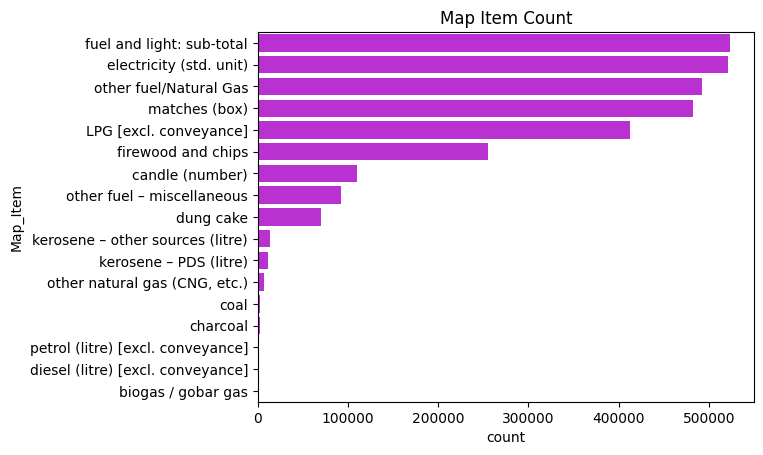

In [65]:
sns.barplot(df['Map_Item'].value_counts(), orient='h')
plt.title('Map Item Count')
plt.show()

In [68]:
df.columns

Index(['Item_Code_8_1', 'Out_of_home_qty_000', 'Out_of_home_value_rs',
       'Total_consumption_qty_000', 'Total_consumption_value_rs', 'Map_Item'],
      dtype='object')

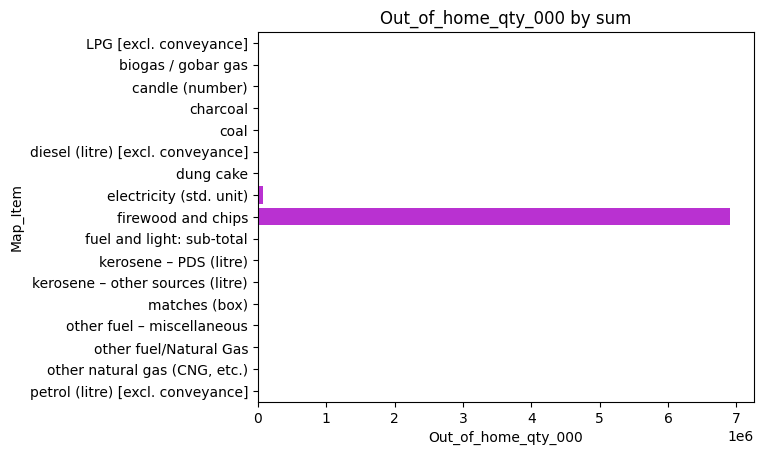

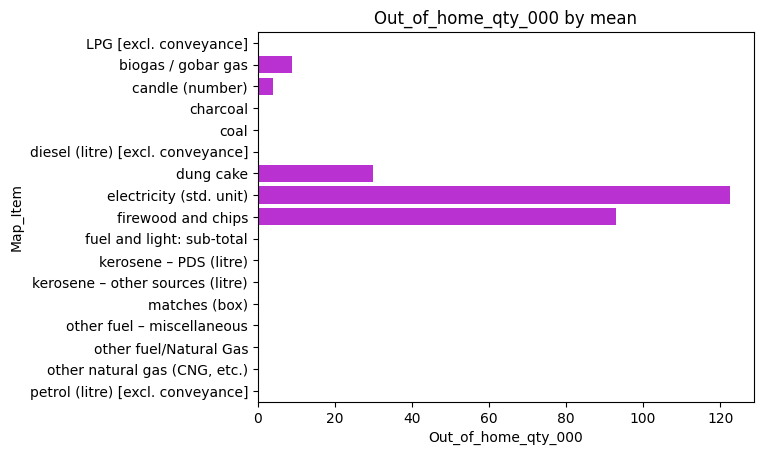

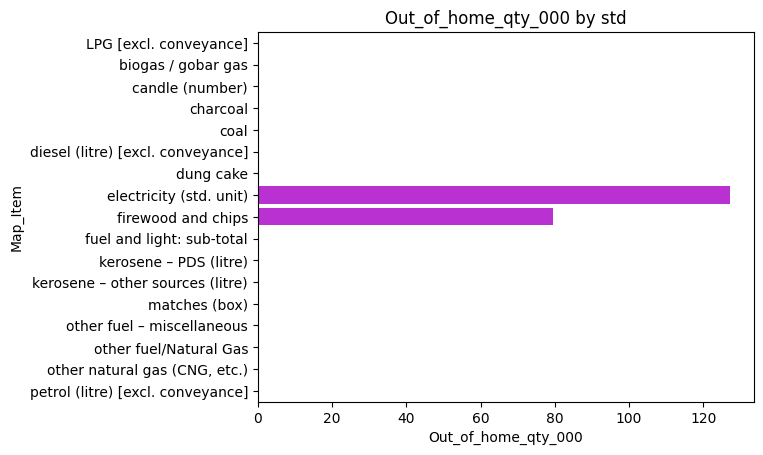

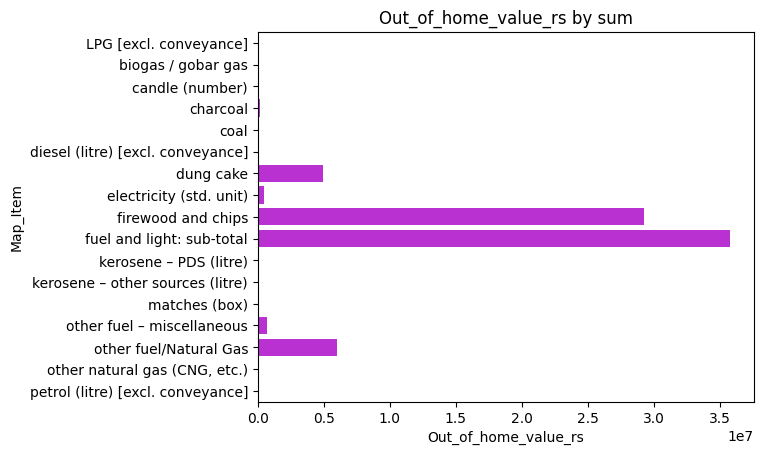

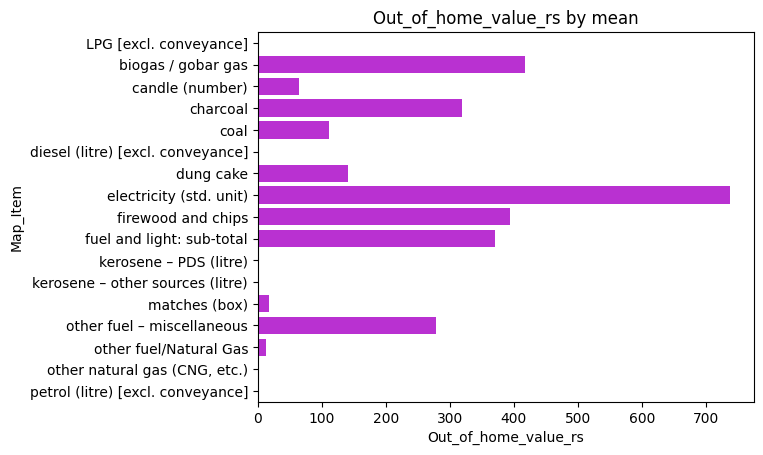

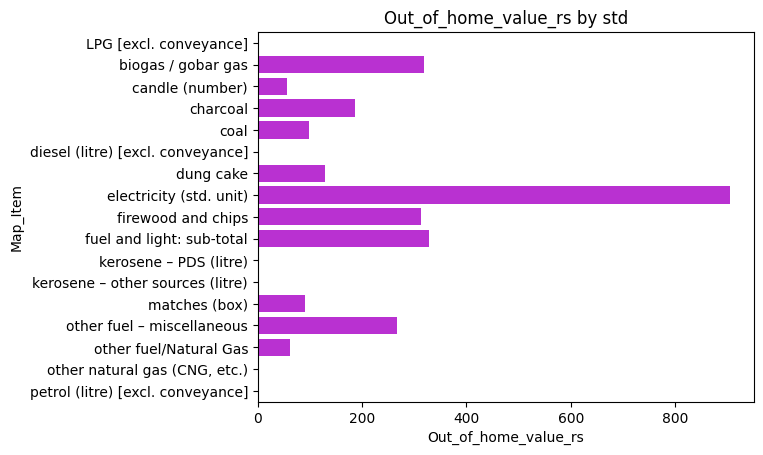

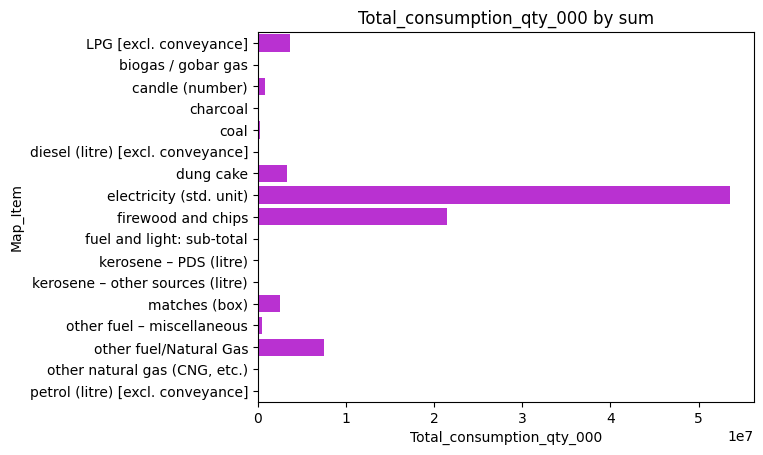

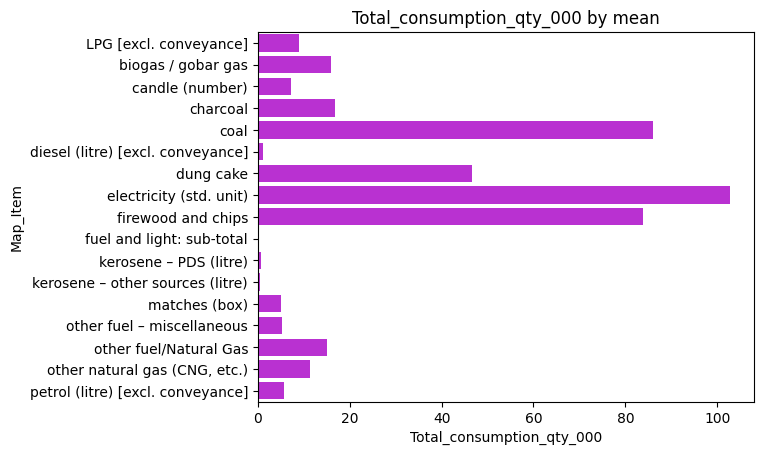

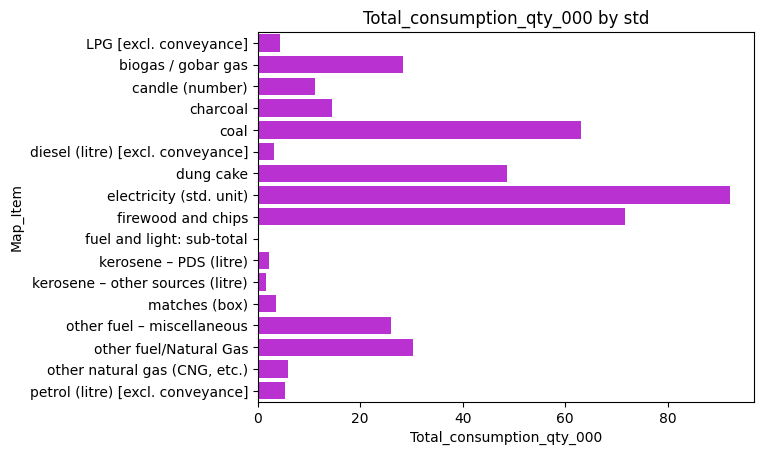

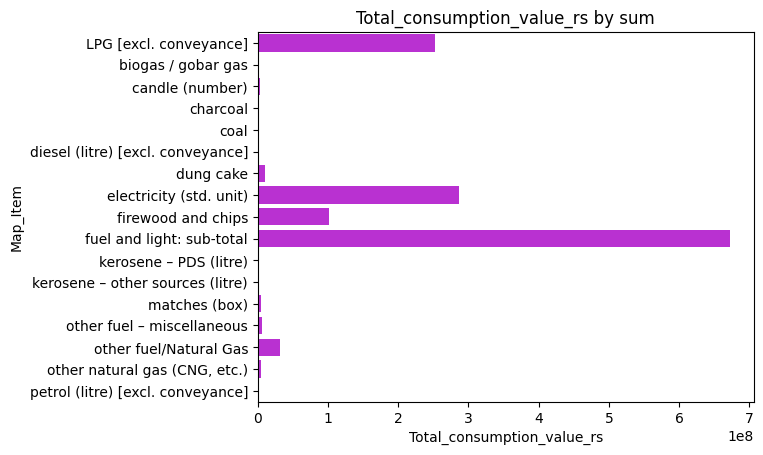

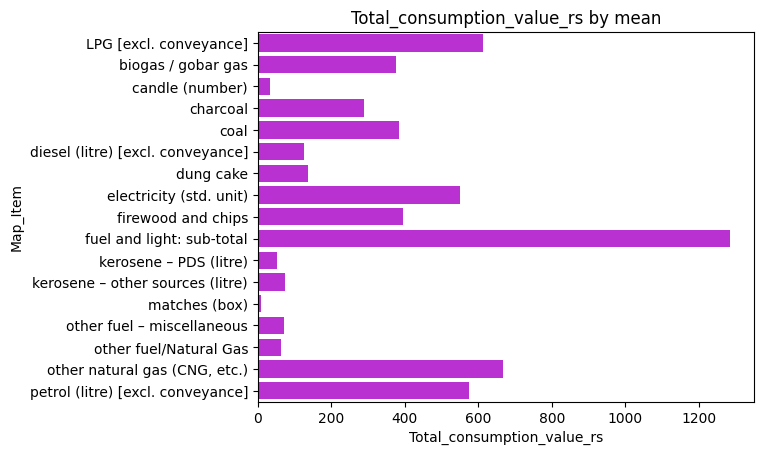

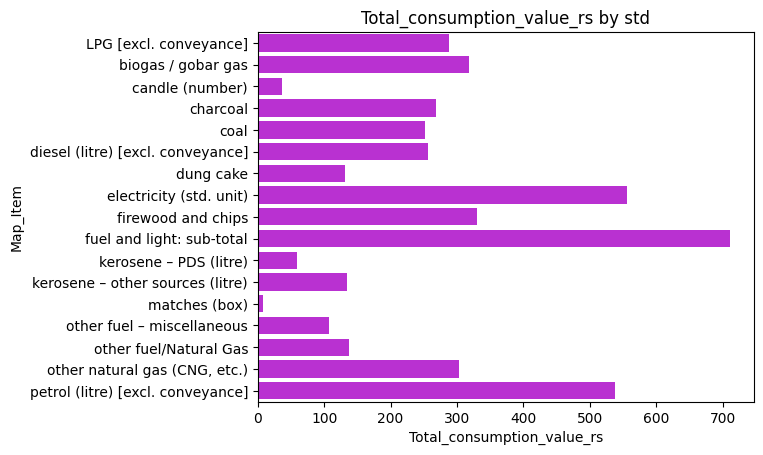

In [77]:
columns = ['Out_of_home_qty_000', 'Out_of_home_value_rs',
       'Total_consumption_qty_000', 'Total_consumption_value_rs']

agg_functions = ['sum', 'mean', 'std']

for col in columns:
       for fun in agg_functions:
              sns.barplot(df.groupby('Map_Item')[col].agg(fun), orient='h')
              plt.title(f"{col} by {fun}")
              plt.show()

<Axes: xlabel='Out_of_home_qty_000', ylabel='Map_Item'>

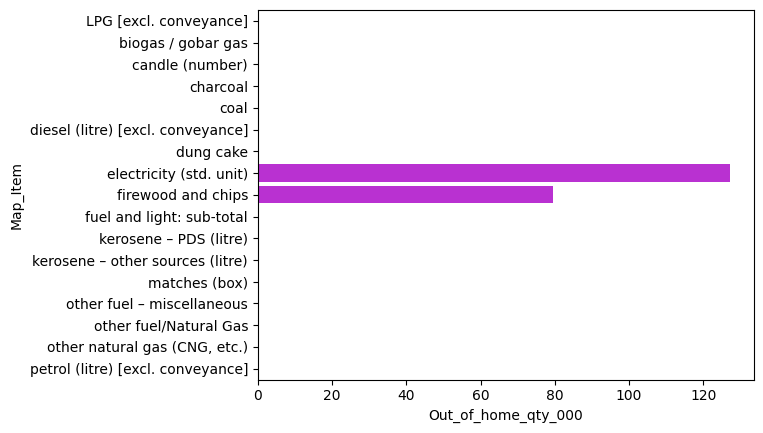

In [74]:
sns.barplot(df.groupby('Map_Item')['Out_of_home_qty_000'].std(), orient='h')